In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.cluster import MiniBatchKMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import lightgbm as lgb
import cupy as cp

In [27]:
data = pd.read_csv('data/US_Accidents_March23.csv')
data.sample(10)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
6402718,A-6449952,Source1,2,2021-02-26 04:51:30.000000000,2021-02-26 18:59:14.000000000,33.927310,-118.268015,33.918054,-118.194772,4.248,...,False,False,False,False,False,False,Night,Night,Night,Night
7108421,A-7157764,Source1,2,2020-04-06 07:24:55,2020-04-06 08:09:53,37.407820,-77.564960,37.423880,-77.581720,1.441,...,False,False,False,False,True,False,Day,Day,Day,Day
571304,A-575796,Source2,2,2022-07-04 05:30:08,2022-07-04 06:20:00,40.612301,-77.325111,NaN,NaN,2.580,...,False,False,False,False,False,False,Night,Day,Day,Day
6930797,A-6980101,Source1,2,2020-05-25 18:26:56,2020-05-25 18:41:56,45.061590,-123.572400,45.061590,-123.572400,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
2749979,A-2759854,Source2,2,2018-06-13 18:30:49,2018-06-13 19:30:32,47.675797,-122.311951,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Night
4741077,A-4777052,Source1,2,2022-12-12 13:59:00,2022-12-12 16:18:37,34.025676,-118.144647,34.025941,-118.144421,0.022,...,False,False,False,False,False,False,Day,Day,Day,Day
330777,A-330787,Source2,3,2017-02-08 07:44:43,2017-02-08 08:30:51,40.589218,-75.589272,NaN,NaN,0.010,...,False,False,False,False,False,False,Day,Day,Day,Day
5902308,A-5946393,Source1,2,2021-12-18 08:52:37,2021-12-18 11:37:45,45.516734,-94.283205,45.515488,-94.284492,0.106,...,False,False,False,False,False,False,Day,Day,Day,Day
3304881,A-3314764,Source2,2,2017-09-18 14:57:15,2017-09-18 16:27:02,28.603769,-81.217850,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
7089304,A-7138643,Source1,2,2020-03-26 20:20:40,2020-03-26 21:05:40,27.699740,-80.904340,27.699740,-80.904340,0.000,...,False,False,False,False,True,False,Night,Night,Day,Day


In [28]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float6

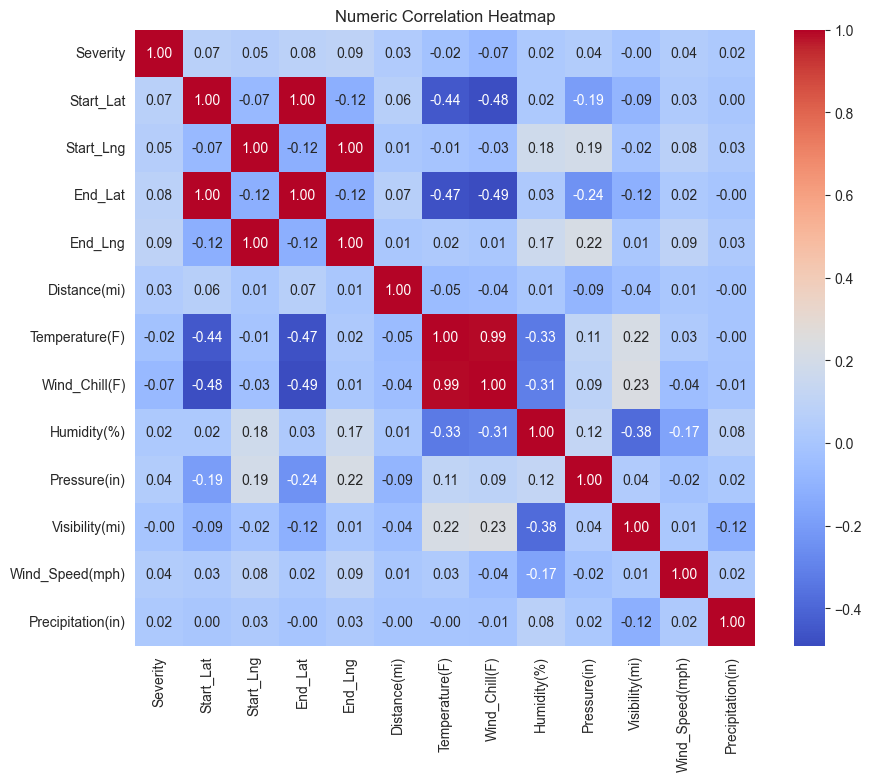

In [29]:
num_data = data.select_dtypes(include=['int64', 'float64'])

corr = num_data.corr(method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Numeric Correlation Heatmap")
plt.show()

In [30]:
data['Start_Time'] = pd.to_datetime(data['Start_Time'], format='mixed')
data['End_Time'] = pd.to_datetime(data['End_Time'], format='mixed')
data['Accident_Duration'] = (data['End_Time'] - data['Start_Time']).dt.total_seconds() / 60
data = data[(data['Accident_Duration'] >= 0) & (data['Accident_Duration'] <= 2880)].copy()

data.drop(columns=['ID','Source','End_Time','End_Lat','End_Lng','Country','Timezone','Weather_Timestamp','Airport_Code','Zipcode','Civil_Twilight','Nautical_Twilight','Astronomical_Twilight','Turning_Loop','Street','Precipitation(in)','Wind_Chill(F)'], inplace=True)
data.sample(5)

,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Description,City,County,State,Temperature(F),...,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Sunrise_Sunset,Accident_Duration
1712156,2,2019-12-17 06:08:11,35.600727,-97.426460,0.000,Accident on John Kilpatrick Tpke Westbound at ...,Edmond,Oklahoma,OK,24.0,...,False,False,False,False,False,False,False,False,Night,29.633333
5408435,2,2022-04-05 17:10:28,32.454075,-90.115153,0.491,Stationary traffic on US-51 S - US-51 N from N...,Madison,Madison,MS,81.0,...,False,False,False,False,False,False,False,False,Day,59.866667
6979016,3,2020-05-14 14:31:28,35.216140,-80.883720,0.000,At Remount Rd - Accident.,Charlotte,Mecklenburg,NC,76.0,...,False,False,False,False,False,False,False,True,Day,30.000000
5213976,2,2022-10-12 22:28:00,38.295748,-122.034171,0.096,Incident on I-80 WB near MANUEL CAMPOS PKY Rig...,Fairfield,Solano,CA,56.0,...,False,False,False,False,False,False,False,False,Night,81.516667
6502868,2,2021-02-17 19:21:56,44.736420,-93.283217,0.058,Incident on I-35W NB near I-35 Drive with caut...,Burnsville,Dakota,MN,7.0,...,False,False,False,False,False,False,False,False,Night,120.633333


In [31]:
# data.drop(columns=['County', 'State'], inplace=True)


In [32]:
data['Year'] = data['Start_Time'].dt.year
data['Hour'] = data['Start_Time'].dt.hour
data['Day_of_week'] = data['Start_Time'].dt.dayofweek
data['Month'] = data['Start_Time'].dt.month
data['Is_rush_hour'] = data['Hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)
data['Is_weekend'] = (data['Day_of_week'] >= 5).astype(int)

data.drop(columns=['Start_Time'], inplace=True)

In [33]:
geo_kmeans = MiniBatchKMeans(n_clusters=200, random_state=42, batch_size=10000, n_init='auto')
data['Geo_Cluster'] = geo_kmeans.fit_predict(data[['Start_Lat', 'Start_Lng']]).astype(str)
print(data['Geo_Cluster'].nunique(), 'geo clusters')

200 geo clusters


In [34]:

weather_map = {
    'Clear': 'Clear',
    'Fair': 'Clear',
    'Fair / Windy': 'Clear',
    'N/A Precipitation': 'Clear',

    'Cloudy': 'Cloudy',
    'Cloudy / Windy': 'Cloudy',
    'Mostly Cloudy': 'Cloudy',
    'Mostly Cloudy / Windy': 'Cloudy',
    'Partly Cloudy': 'Cloudy',
    'Partly Cloudy / Windy': 'Cloudy',
    'Scattered Clouds': 'Cloudy',
    'Overcast': 'Cloudy',

    'Drizzle': 'Rain',
    'Drizzle / Windy': 'Rain',
    'Drizzle and Fog': 'Rain',
    'Heavy Drizzle': 'Rain',
    'Heavy Rain': 'Rain',
    'Heavy Rain / Windy': 'Rain',
    'Heavy Rain Shower': 'Rain',
    'Heavy Rain Shower / Windy': 'Rain',
    'Heavy Rain Showers': 'Rain',
    'Light Drizzle': 'Rain',
    'Light Drizzle / Windy': 'Rain',
    'Light Freezing Rain': 'Rain',
    'Light Freezing Rain / Windy': 'Rain',
    'Light Rain': 'Rain',
    'Light Rain / Windy': 'Rain',
    'Light Rain Shower': 'Rain',
    'Light Rain Shower / Windy': 'Rain',
    'Light Rain Showers': 'Rain',
    'Light Rain with Thunder': 'Rain',
    'Rain': 'Rain',
    'Rain / Windy': 'Rain',
    'Rain Shower': 'Rain',
    'Rain Shower / Windy': 'Rain',
    'Rain Showers': 'Rain',
    'Rain and Sleet': 'Rain',
    'Freezing Rain': 'Rain',
    'Freezing Rain / Windy': 'Rain',
    'Heavy Freezing Rain': 'Rain',
    'Heavy Freezing Rain / Windy': 'Rain',
    'Showers in the Vicinity': 'Rain',

    'Blowing Snow': 'Snow',
    'Blowing Snow / Windy': 'Snow',
    'Blowing Snow Nearby': 'Snow',
    'Drifting Snow': 'Snow',
    'Drifting Snow / Windy': 'Snow',
    'Freezing Drizzle': 'Snow',
    'Heavy Blowing Snow': 'Snow',
    'Heavy Freezing Drizzle': 'Snow',
    'Heavy Ice Pellets': 'Snow',
    'Heavy Snow': 'Snow',
    'Heavy Snow / Windy': 'Snow',
    'Heavy Snow with Thunder': 'Snow',
    'Heavy Thunderstorms and Snow': 'Snow',
    'Ice Pellets': 'Snow',
    'Light Blowing Snow': 'Snow',
    'Light Freezing Drizzle': 'Snow',
    'Light Ice Pellets': 'Snow',
    'Light Snow': 'Snow',
    'Light Snow / Windy': 'Snow',
    'Light Snow Grains': 'Snow',
    'Light Snow Shower': 'Snow',
    'Light Snow Shower / Windy': 'Snow',
    'Light Snow Showers': 'Snow',
    'Light Snow and Sleet': 'Snow',
    'Light Snow and Sleet / Windy': 'Snow',
    'Light Snow with Thunder': 'Snow',
    'Light Thunderstorms and Snow': 'Snow',
    'Low Drifting Snow': 'Snow',
    'Sleet': 'Snow',
    'Sleet / Windy': 'Snow',
    'Sleet and Thunder': 'Snow',
    'Snow': 'Snow',
    'Snow / Windy': 'Snow',
    'Snow Grains': 'Snow',
    'Snow Showers': 'Snow',
    'Snow and Sleet': 'Snow',
    'Snow and Sleet / Windy': 'Snow',
    'Snow and Thunder': 'Snow',
    'Snow and Thunder / Windy': 'Snow',
    'Light Sleet': 'Snow',
    'Light Sleet / Windy': 'Snow',
    'Heavy Sleet': 'Snow',
    'Heavy Sleet / Windy': 'Snow',
    'Heavy Sleet and Thunder': 'Snow',
    'Wintry Mix': 'Snow',
    'Wintry Mix / Windy': 'Snow',
    'Thunder / Wintry Mix': 'Snow',
    'Thunder / Wintry Mix / Windy': 'Snow',

    'Fog': 'Fog',
    'Fog / Windy': 'Fog',
    'Freezing Fog': 'Fog',
    'Haze': 'Fog',
    'Haze / Windy': 'Fog',
    'Heavy Smoke': 'Fog',
    'Light Fog': 'Fog',
    'Light Freezing Fog': 'Fog',
    'Light Haze': 'Fog',
    'Mist': 'Fog',
    'Mist / Windy': 'Fog',
    'Partial Fog': 'Fog',
    'Partial Fog / Windy': 'Fog',
    'Patches of Fog': 'Fog',
    'Patches of Fog / Windy': 'Fog',
    'Shallow Fog': 'Fog',
    'Shallow Fog / Windy': 'Fog',
    'Smoke': 'Fog',
    'Smoke / Windy': 'Fog',

    'Blowing Dust': 'Dust_Sand',
    'Blowing Dust / Windy': 'Dust_Sand',
    'Blowing Sand': 'Dust_Sand',
    'Dust Whirls': 'Dust_Sand',
    'Duststorm': 'Dust_Sand',
    'Sand': 'Dust_Sand',
    'Sand / Windy': 'Dust_Sand',
    'Sand / Dust Whirlwinds': 'Dust_Sand',
    'Sand / Dust Whirlwinds / Windy': 'Dust_Sand',
    'Sand / Dust Whirls Nearby': 'Dust_Sand',
    'Widespread Dust': 'Dust_Sand',
    'Widespread Dust / Windy': 'Dust_Sand',
    'Volcanic Ash': 'Dust_Sand',

    'Funnel Cloud': 'Storm',
    'Hail': 'Storm',
    'Heavy T-Storm': 'Storm',
    'Heavy T-Storm / Windy': 'Storm',
    'Heavy Thunderstorms and Rain': 'Storm',
    'Heavy Thunderstorms with Small Hail': 'Storm',
    'Light Hail': 'Storm',
    'Light Thunderstorm': 'Storm',
    'Light Thunderstorms and Rain': 'Storm',
    'Small Hail': 'Storm',
    'Squalls': 'Storm',
    'Squalls / Windy': 'Storm',
    'T-Storm': 'Storm',
    'T-Storm / Windy': 'Storm',
    'Thunder': 'Storm',
    'Thunder / Windy': 'Storm',
    'Thunder and Hail': 'Storm',
    'Thunder and Hail / Windy': 'Storm',
    'Thunder in the Vicinity': 'Storm',
    'Thunderstorm': 'Storm',
    'Thunderstorms and Rain': 'Storm',
    'Thunderstorms and Snow': 'Storm',
    'Tornado': 'Storm',
}

data['weather_group'] = data['Weather_Condition'].map(weather_map).fillna('Other')

unmapped = data[data['weather_group'] == 'Other']['Weather_Condition'].unique()
print("Unmapped conditions:", unmapped)

data.drop(columns=['Weather_Condition'], inplace=True)

Unmapped conditions: <StringArray>
[nan]
Length: 1, dtype: str


In [35]:
wind_map = {
    'N': 'North', 'North': 'North', 'NNE': 'North', 'NNW': 'North',

    'NE': 'Northeast', 'ENE': 'Northeast',

    'E': 'East', 'East': 'East', 'ESE': 'East',

    'SE': 'Southeast', 'SSE': 'Southeast',

    'S': 'South', 'South': 'South', 'SSW': 'South',

    'SW': 'Southwest', 'WSW': 'Southwest',

    'W': 'West', 'West': 'West', 'WNW': 'West',

    'NW': 'Northwest',

    'Calm': 'Calm', 'CALM': 'Calm',

    'Variable': 'Variable', 'VAR': 'Variable',
}

data['Wind_Group'] = data['Wind_Direction'].map(wind_map)
data['Wind_Group'] = data['Wind_Group'].fillna(data['Wind_Group'].mode()[0])
data.drop(columns=['Wind_Direction'], inplace=True)
print(data['Wind_Group'].value_counts())

Wind_Group
Calm         1503168
North        1047443
South         981030
West          926487
Southwest     717584
East          649715
Southeast     642867
Northeast     516225
Northwest     368840
Variable      364153
Name: count, dtype: int64


In [36]:
missing = data.isnull().sum()
missing = missing[missing > 0]
print(missing.sort_values(ascending=False))
print("\nAs percentage:")
print((missing / len(data) * 100).round(2))

Wind_Speed(mph)    570684
Visibility(mi)     176809
Humidity(%)        173870
Temperature(F)     163595
Pressure(in)       140508
Sunrise_Sunset      23045
City                  253
Description             5
dtype: int64

As percentage:
Description        0.00
City               0.00
Temperature(F)     2.12
Humidity(%)        2.25
Pressure(in)       1.82
Visibility(mi)     2.29
Wind_Speed(mph)    7.39
Sunrise_Sunset     0.30
dtype: float64


In [37]:
for col in ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)']:
    data[col] = data[col].fillna(data[col].median())

data['Sunrise_Sunset'] = data['Sunrise_Sunset'].fillna(data['Sunrise_Sunset'].mode()[0])

data['City'] = data['City'].fillna('Unknown')

print(data.isnull().sum().sum())

5


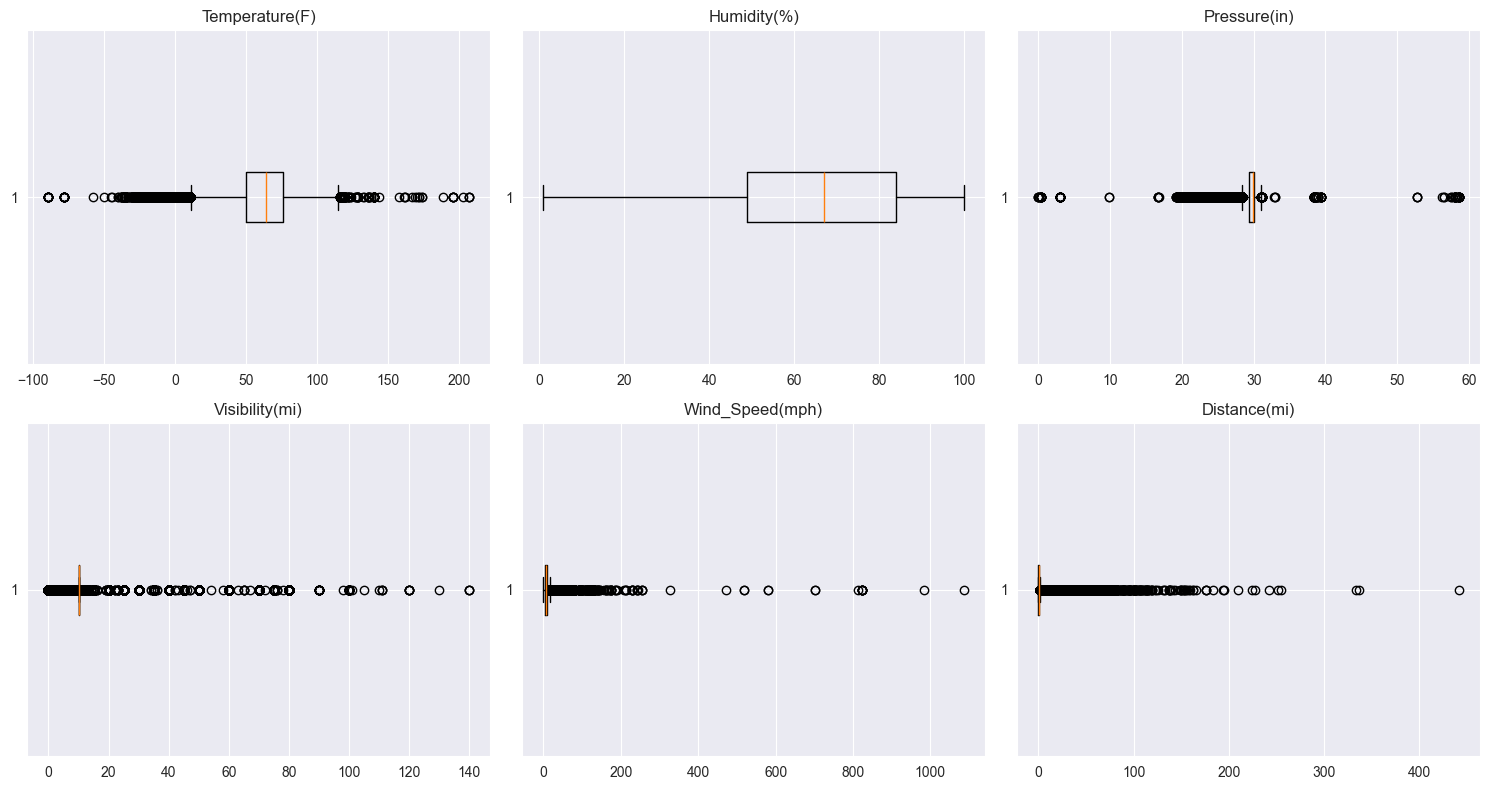

In [38]:
import matplotlib.pyplot as plt

numerical_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)',
                  'Visibility(mi)', 'Wind_Speed(mph)', 'Distance(mi)']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(data[col].dropna(), vert=False)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [39]:
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)].shape[0]
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}, outliers={outliers} ({outliers/len(data)*100:.2f}%)")

Temperature(F): lower=11.00, upper=115.00, outliers=65251 (0.85%)
Humidity(%): lower=-3.50, upper=136.50, outliers=0 (0.00%)
Pressure(in): lower=28.40, upper=31.01, outliers=448001 (5.80%)
Visibility(mi): lower=10.00, upper=10.00, outliers=1479210 (19.17%)
Wind_Speed(mph): lower=-2.50, upper=17.50, outliers=290415 (3.76%)
Distance(mi): lower=-0.69, upper=1.16, outliers=963946 (12.49%)


In [40]:
def cap_outliers(df, col, lower, upper):
    df[col] = df[col].clip(lower=lower, upper=upper)

cap_outliers(data, 'Temperature(F)', lower=-50, upper=130)

cap_outliers(data, 'Pressure(in)', lower=27.0, upper=32.0)

cap_outliers(data, 'Wind_Speed(mph)', lower=0, upper=74)

print("Done. Verify:")
for col in ['Temperature(F)', 'Pressure(in)', 'Wind_Speed(mph)']:
    print(f"{col}: min={data[col].min():.2f}, max={data[col].max():.2f}")

Done. Verify:
Temperature(F): min=-50.00, max=130.00
Pressure(in): min=27.00, max=32.00
Wind_Speed(mph): min=0.00, max=74.00


In [41]:
print(data['Pressure(in)'].describe())

count    7.717512e+06
mean     2.960655e+01
std      7.145249e-01
min      2.700000e+01
25%      2.938000e+01
50%      2.986000e+01
75%      3.003000e+01
max      3.200000e+01
Name: Pressure(in), dtype: float64


In [42]:
print(data['Wind_Speed(mph)'].describe())

count    7.717512e+06
mean     7.631807e+00
std      5.073812e+00
min      0.000000e+00
25%      5.000000e+00
50%      7.000000e+00
75%      1.000000e+01
max      7.400000e+01
Name: Wind_Speed(mph), dtype: float64


In [43]:
categorical_cols = data.select_dtypes(include=['object', 'bool']).columns.tolist()
print(categorical_cols)

['Description', 'City', 'County', 'State', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Sunrise_Sunset', 'Geo_Cluster', 'weather_group', 'Wind_Group']


C:\Users\Ana\AppData\Local\Temp\ipykernel_17416\378198734.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=['object', 'bool']).columns.tolist()


In [44]:
bool_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
             'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
             'Traffic_Signal']
data[bool_cols] = data[bool_cols].astype(int)

data = pd.get_dummies(data, columns=['Sunrise_Sunset', 'weather_group', 'Wind_Group'],
                      drop_first=True, dtype=int)
print(data.shape)

(7717512, 50)


Severity
2    6148204
3    1299111
4     202834
1      67363
Name: count, dtype: int64

As percentage:
Severity
2    79.67
3    16.83
4     2.63
1     0.87
Name: count, dtype: float64


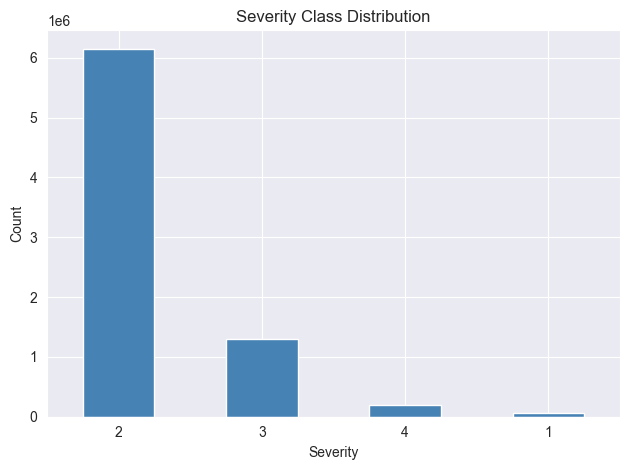

In [45]:
import matplotlib.pyplot as plt

print(data['Severity'].value_counts())
print("\nAs percentage:")
print((data['Severity'].value_counts() / len(data) * 100).round(2))

data['Severity'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Severity Class Distribution')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
high_card = ['City', 'County', 'State', 'Geo_Cluster']
num_cols = ['Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)',
            'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Accident_Duration'] + high_card

train = data[data['Year'] <= 2020].copy()
val   = data[data['Year'] == 2021].copy()
test  = data[data['Year'] == 2022].copy()

desc_train = train['Description'].fillna('').reset_index(drop=True)
desc_val = val['Description'].fillna('').reset_index(drop=True)
desc_test = test['Description'].fillna('').reset_index(drop=True)

drop_cols = ['Severity', 'Year', 'Description']
X_train = train.drop(columns=drop_cols).reset_index(drop=True)
X_val = val.drop(columns=drop_cols).reset_index(drop=True)
X_test = test.drop(columns=drop_cols).reset_index(drop=True)
y_train = train['Severity'].reset_index(drop=True)
y_val = val['Severity'].reset_index(drop=True)
y_test = test['Severity'].reset_index(drop=True)

te = TargetEncoder(target_type='continuous', random_state=42)
X_train[high_card] = te.fit_transform(X_train[high_card], y_train)
X_val[high_card] = te.transform(X_val[high_card])
X_test[high_card] = te.transform(X_test[high_card])

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print('train', X_train.shape, 'val', X_val.shape, 'test', X_test.shape)
print(y_train.value_counts().to_dict())
print(y_test.value_counts().to_dict())

train (4151593, 47) val (1558723, 47) test (1760749, 47)
{2: 2926701, 3: 1073137, 4: 122418, 1: 29337}
{2: 1601935, 3: 77947, 4: 42992, 1: 37875}


In [47]:
tfidf = TfidfVectorizer(max_features=40, stop_words='english', ngram_range=(1, 2), min_df=50)
Xtr_txt = tfidf.fit_transform(desc_train)
Xv_txt = tfidf.transform(desc_val)
Xte_txt = tfidf.transform(desc_test)
txt_cols = ['tfidf_' + t for t in tfidf.get_feature_names_out()]

X_train = pd.concat([X_train, pd.DataFrame(Xtr_txt.toarray().astype(np.float32), columns=txt_cols)], axis=1)
X_val = pd.concat([X_val, pd.DataFrame(Xv_txt.toarray().astype(np.float32), columns=txt_cols)], axis=1)
X_test = pd.concat([X_test, pd.DataFrame(Xte_txt.toarray().astype(np.float32), columns=txt_cols)], axis=1)
print('with text features:', X_train.shape)

with text features: (4151593, 87)


In [48]:
counts = y_train.value_counts()
maj_target = min(int(counts.get(2, 0)), 1000000)

over_strategy = {
    1: 150000,
    4: 500000,
}

resampler = ImbPipeline([
    ('under', RandomUnderSampler(sampling_strategy={2: maj_target}, random_state=42)),
    ('over', SMOTE(sampling_strategy=over_strategy, random_state=42, k_neighbors=5)),
])
X_train_res, y_train_res = resampler.fit_resample(X_train, y_train)

print(pd.Series(y_train_res).value_counts().to_dict())

{3: 1073137, 2: 1000000, 4: 500000, 1: 150000}


In [49]:
print(y_test.value_counts())

Severity
2    1601935
3      77947
4      42992
1      37875
Name: count, dtype: int64


Logistic Regression...


C:\Users\Ana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: macro-F1=0.4846  acc=0.8282  (1228.2s)
Random Forest...
Random Forest: macro-F1=0.4932  acc=0.8593  (180.3s)
XGBoost...
XGBoost: macro-F1=0.4785  acc=0.8498  (21.9s)
LightGBM...
LightGBM: macro-F1=0.4905  acc=0.8717  (83.7s)
Balanced Bagging...
Balanced Bagging: macro-F1=0.3283  acc=0.6876  (116.8s)
              Model  Macro F1  Accuracy  Time (s)
      Random Forest  0.493233  0.859289     180.3
           LightGBM  0.490495  0.871687      83.7
Logistic Regression  0.484575  0.828205    1228.2
            XGBoost  0.478548  0.849836      21.9
   Balanced Bagging  0.328257  0.687599     116.8


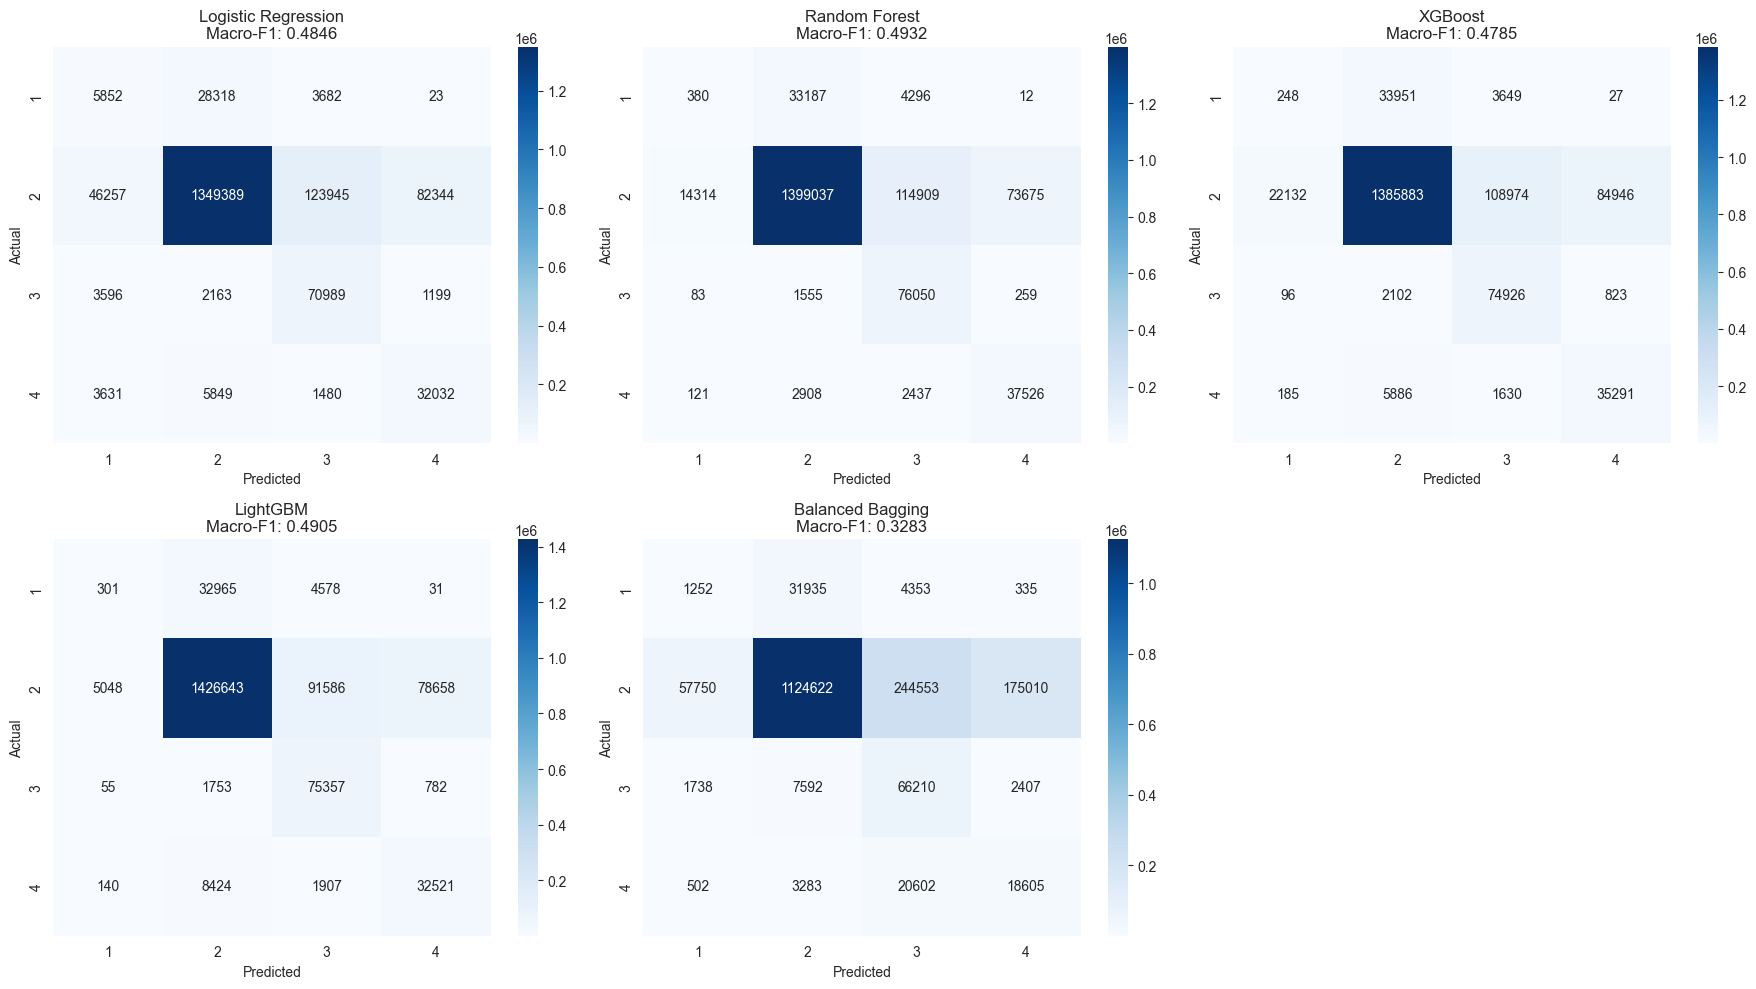


========== Logistic Regression ==========
              precision    recall  f1-score   support

           1       0.10      0.15      0.12     37875
           2       0.97      0.84      0.90   1601935
           3       0.35      0.91      0.51     77947
           4       0.28      0.75      0.40     42992

    accuracy                           0.83   1760749
   macro avg       0.43      0.66      0.48   1760749
weighted avg       0.91      0.83      0.86   1760749


========== Random Forest ==========
              precision    recall  f1-score   support

           1       0.03      0.01      0.01     37875
           2       0.97      0.87      0.92   1601935
           3       0.38      0.98      0.55     77947
           4       0.34      0.87      0.49     42992

    accuracy                           0.86   1760749
   macro avg       0.43      0.68      0.49   1760749
weighted avg       0.91      0.86      0.87   1760749


========== XGBoost ==========
              preci

In [50]:
results = {}

def evaluate(name, y_true, y_pred, elapsed):
    results[name] = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'time': elapsed,
        'report': classification_report(y_true, y_pred),
        'cm': confusion_matrix(y_true, y_pred),
    }
    print(f"{name}: macro-F1={results[name]['macro_f1']:.4f}  acc={results[name]['accuracy']:.4f}  ({elapsed:.1f}s)")

print("Logistic Regression...")
start = time.time()
lr = LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42,
                        class_weight='balanced')
lr.fit(X_train_res, y_train_res)
evaluate('Logistic Regression', y_test, lr.predict(X_test), time.time() - start)

print("Random Forest...")
start = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_split=50,
                            min_samples_leaf=20, n_jobs=-1, random_state=42,
                            class_weight='balanced')
rf.fit(X_train_res, y_train_res)
evaluate('Random Forest', y_test, rf.predict(X_test), time.time() - start)

print("XGBoost...")
start = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8, random_state=42,
                              eval_metric='mlogloss', device='cuda', tree_method='hist')
sw = compute_sample_weight('balanced', y_train_res - 1)
xgb_model.fit(X_train_res, y_train_res - 1, sample_weight=sw)

X_test_gpu = cp.array(X_test)
y_pred_xgb = xgb_model.predict(X_test_gpu) + 1
evaluate('XGBoost', y_test, y_pred_xgb, time.time() - start)

print("LightGBM...")
start = time.time()
lgb_model = lgb.LGBMClassifier(n_estimators=200, max_depth=10, learning_rate=0.1,
                               num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                               random_state=42, class_weight='balanced', device='gpu', verbose=-1)
lgb_model.fit(X_train_res, y_train_res)
evaluate('LightGBM', y_test, lgb_model.predict(X_test), time.time() - start)

print("Balanced Bagging...")
start = time.time()
bb = BalancedBaggingClassifier(n_estimators=15, random_state=42, n_jobs=-1)
bb.fit(X_train, y_train)
evaluate('Balanced Bagging', y_test, bb.predict(X_test), time.time() - start)

summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Macro F1': [v['macro_f1'] for v in results.values()],
    'Accuracy': [v['accuracy'] for v in results.values()],
    'Time (s)': [round(v['time'], 1) for v in results.values()],
}).sort_values('Macro F1', ascending=False)
print(summary.to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (name, res) in enumerate(results.items()):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
    axes[i].set_title(f"{name}\nMacro-F1: {res['macro_f1']:.4f}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
for j in range(len(results), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

for name, res in results.items():
    print(f"\n========== {name} ==========")
    print(res['report'])